In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [2]:
DATASET_PATH = "/kaggle/input/datasets/muhammadanasfaisal/pai-project-dataseet-2/pai_proj_dataset"
IMG_SIZE = 128
BATCH_SIZE = 30
EPOCHS = 20
LR = 0.001

CLASS_NAMES = ["ripe_tomato", "bad_tomato", "ripe_banana", "bad_banana"]
NUM_CLASSES = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [3]:
class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [4]:
FOLDER_CLASSES = ["bad_tomato", "ripe_tomato" , "ripe_banana", "bad_banana"] 

def load_paths():
    paths = []
    labels = []

    for cls in FOLDER_CLASSES:
        folder = os.path.join(DATASET_PATH, cls)

        for file in os.listdir(folder):
            paths.append(os.path.join(folder, file))

            if cls == "ripe_tomato": #ripe ka label 0
                labels.append(0)
            elif cls == "bad_tomato":
                labels.append(1)
            elif cls == "ripe_banana":
                labels.append(2)
            elif cls == "bad_banana":
                labels.append(3)
                

    return np.array(paths), np.array(labels)


paths, labels = load_paths()

print("Total images:", len(paths))

Total images: 3650


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 2920, Test: 730


In [6]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.2),
    transforms.ToTensor()
])

test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_ds = CustomDataset(X_train, y_train, train_tf)
test_ds = CustomDataset(X_test, y_test, test_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [7]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)


model = MyModel().to(device)
print(model)


MyModel(
  (block1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(32, 64, 

In [8]:
def train(model, loader, optimizer, loss_fn):
    model.train()
    total_loss, correct = 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(X)
        loss = loss_fn(preds, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (preds.argmax(1) == y).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, correct = 0, 0

    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            preds = model(X)
            loss = loss_fn(preds, y)

            total_loss += loss.item()

            predicted = preds.argmax(1)
            correct += (predicted == y).sum().item()

            all_preds.append(predicted.cpu())
            all_labels.append(y.cpu())

    return (
        total_loss / len(loader),
        correct / len(loader.dataset),
        torch.cat(all_preds),
        torch.cat(all_labels)
    )

In [9]:

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []
for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, loss_fn)
    train_losses.append(train_loss)
    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print("-" * 40)

Epoch 1
Train Loss: 0.8828 | Train Acc: 0.6692
----------------------------------------
Epoch 2
Train Loss: 0.4861 | Train Acc: 0.7757
----------------------------------------
Epoch 3
Train Loss: 0.4333 | Train Acc: 0.7986
----------------------------------------
Epoch 4
Train Loss: 0.3984 | Train Acc: 0.8062
----------------------------------------
Epoch 5
Train Loss: 0.3697 | Train Acc: 0.8291
----------------------------------------
Epoch 6
Train Loss: 0.3621 | Train Acc: 0.8229
----------------------------------------
Epoch 7
Train Loss: 0.3493 | Train Acc: 0.8332
----------------------------------------
Epoch 8
Train Loss: 0.3427 | Train Acc: 0.8387
----------------------------------------
Epoch 9
Train Loss: 0.3406 | Train Acc: 0.8445
----------------------------------------
Epoch 10
Train Loss: 0.3159 | Train Acc: 0.8408
----------------------------------------
Epoch 11
Train Loss: 0.3335 | Train Acc: 0.8432
----------------------------------------
Epoch 12
Train Loss: 0.3186 | 

In [12]:
test_loss, test_acc, preds, labels = evaluate(model, test_loader, loss_fn)

print("\nTEST ACC:", test_acc)

print("\nClassification Report")
print(classification_report(labels, preds, target_names=CLASS_NAMES))


TEST ACC: 0.9506849315068493

Classification Report
              precision    recall  f1-score   support

 ripe_tomato       0.89      0.96      0.92       181
  bad_tomato       0.95      0.85      0.89       144
 ripe_banana       0.98      0.99      0.98       203
  bad_banana       0.99      0.98      0.98       202

    accuracy                           0.95       730
   macro avg       0.95      0.94      0.95       730
weighted avg       0.95      0.95      0.95       730



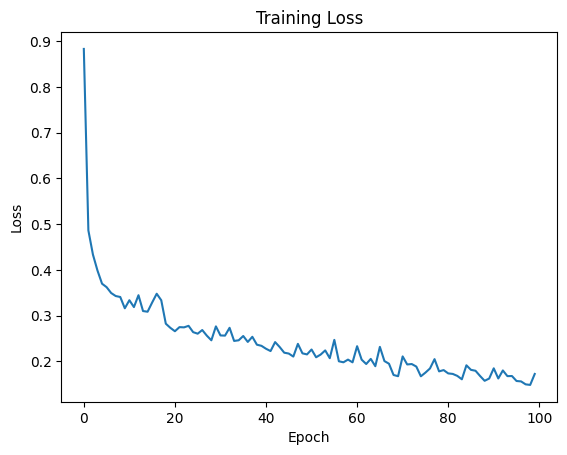

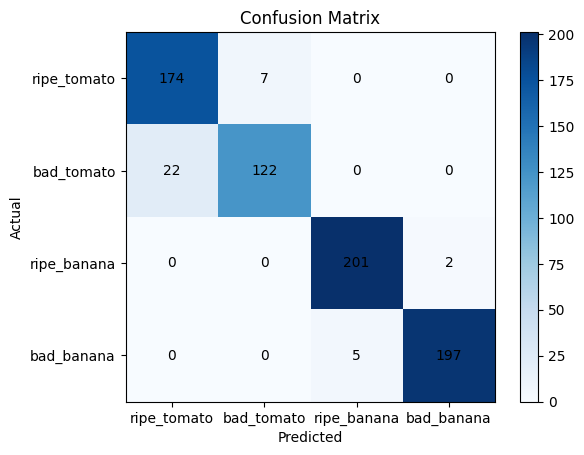

In [13]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


cm = confusion_matrix(labels, preds)

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks(range(NUM_CLASSES), CLASS_NAMES)
plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
MODEL_PATH = "/kaggle/working/PAI_proj_model.pth"

torch.save(model.state_dict(), MODEL_PATH)

print("Model saved at:", MODEL_PATH)
print(os.listdir("/kaggle/working"))

Model saved at: /kaggle/working/PAI_proj_model.pth
['.virtual_documents', 'PAI_proj_model.pth']
